In [ ]:
import os
import random
import shutil
from astropy.io import fits

# Definir los directorios de origen y destino
src_folder = "spectrums"
dst_folder = "spectrums training 100k"

# Crear la carpeta de destino si no existe
if not os.path.exists(dst_folder):
    os.makedirs(dst_folder)

# Definir los rangos de redshift y los mínimos requeridos
bin_ranges = [(0, 0.1), (0.1, 1), (1, 2), (2, 3), (3, 4), (4, 5), (5, 6), (6, 7), (7, 8)]
min_required_values = {
    (0, 0.1): 20000,
    (0.1, 1): 15000,
    (1, 2): 20000,
    (2, 3): 15000,
    (3, 4): 5000,
    (4, 5): 2000,
    (5, 6): 900,
    (6, 7): 850,
    (7, 8): 240
}

# Diccionario para almacenar los archivos clasificados por rango de redshift
files_by_bin = {br: [] for br in bin_ranges}

# Recorrer todos los archivos en el directorio de origen
for file in os.listdir(src_folder):
    if file.lower().endswith(".fits"):
        src_path = os.path.join(src_folder, file)
        try:
            with fits.open(src_path) as hdul:
                redshift = hdul[2].data["Z"][0]
                # Clasificar el archivo en el rango correspondiente
                for br in bin_ranges:
                    lower, upper = br
                    if lower <= redshift < upper:
                        files_by_bin[br].append(file)
                        break
        except Exception as e:
            print(f"Error procesando {file}: {e}")

# Verificar si se cumplen los mínimos requeridos en cada rango
for br in bin_ranges:
    lower, upper = br
    count = len(files_by_bin[br])
    min_required = min_required_values[br]
    if count < min_required:
        print(f"Rango {lower} - {upper}: {count} archivos disponibles (NO cumple con el mínimo de {min_required})")
        print("Por favor, asegúrate de que hay suficientes archivos en cada rango antes de continuar.")
        exit(1)
    else:
        print(f"Rango {lower} - {upper}: {count} archivos disponibles (cumple con el mínimo de {min_required})")

# Seleccionar y copiar los archivos necesarios de cada rango
for br in bin_ranges:
    selected_files = random.sample(files_by_bin[br], min_required_values[br])
    for file in selected_files:
        src_path = os.path.join(src_folder, file)
        dst_path = os.path.join(dst_folder, file)
        shutil.copy(src_path, dst_path)
        print(f"Copiado: {file}")

print("Copia completada.")

In [ ]:
import os
import random
import shutil
import pickle
from astropy.io import fits

# Directorios de origen y destino
src_folder = "spectrums"
dst_folder = "spectrums training 100k"

# Crear el directorio de destino si no existe
if not os.path.exists(dst_folder):
    os.makedirs(dst_folder)

# Definir los dos intervalos de redshift (ejemplo)
target_range1 = (0.1, 2)   # Primer intervalo: de 0.1 a 1
target_range2 = (0.0, 0.1)   # Segundo intervalo: de 2.1 a 3

# Número de archivos a copiar (total de ambos intervalos)
num_files_to_add = 5000

# Obtener la lista de todos los archivos .fits en el directorio de origen
all_files = [file for file in os.listdir(src_folder) if file.lower().endswith(".fits")]

# Randomizar la lista de archivos
random.shuffle(all_files)

# Diccionario para almacenar los redshifts de los archivos que se seleccionen
redshift_dict = {}

# Lista para almacenar los archivos seleccionados
selected_files = []
count = 0

# Recorrer la lista randomizada hasta alcanzar el número deseado
for file in all_files:
    src_path = os.path.join(src_folder, file)
    try:
        with fits.open(src_path) as hdul:
            redshift = hdul[2].data["Z"][0]
            # Verificar si el redshift se encuentra en alguno de los intervalos definidos
            if (target_range1[0] <= redshift < target_range1[1]) or (target_range2[0] <= redshift < target_range2[1]):
                dst_path = os.path.join(dst_folder, file)
                # Si el archivo ya existe en el destino, se "borra" el redshift (es decir, no se agrega)
                if os.path.exists(dst_path):
                    if file in redshift_dict:
                        del redshift_dict[file]
                    continue  # Omitir el archivo ya existente
                # Agregar el archivo a la lista de selección y almacenar su redshift
                selected_files.append(file)
                redshift_dict[file] = redshift
                count += 1
                if count % 100 == 0:
                    print(f"{count} archivos seleccionados...")
                if count >= num_files_to_add:
                    break
    except Exception as e:
        print(f"Error procesando {file}: {e}")

# Verificar si se han encontrado suficientes archivos
if len(selected_files) < num_files_to_add:
    print(f"Se encontraron solo {len(selected_files)} archivos válidos en los intervalos especificados, se requieren {num_files_to_add}.")
    exit(1)
else:
    print(f"Se seleccionaron {len(selected_files)} archivos que cumplen con los intervalos requeridos.")

# Copiar los archivos seleccionados al directorio de destino
for file in selected_files:
    src_path = os.path.join(src_folder, file)
    dst_path = os.path.join(dst_folder, file)
    shutil.copy(src_path, dst_path)
    print(f"Copiado: {file}")

print("Proceso de copia completado.")

# Guardar/actualizar los nuevos redshifts en un archivo pickle
new_redshifts_file = "extra/new_redshifts.pkl"

with open(new_redshifts_file, "wb") as f:
    pickle.dump(redshift_dict, f)

print(f"Se han guardado los nuevos redshifts en '{new_redshifts_file}'.")

100 archivos seleccionados...


Guardado redshift_array con 58013 elementos en 'redshift_array.pkl'.


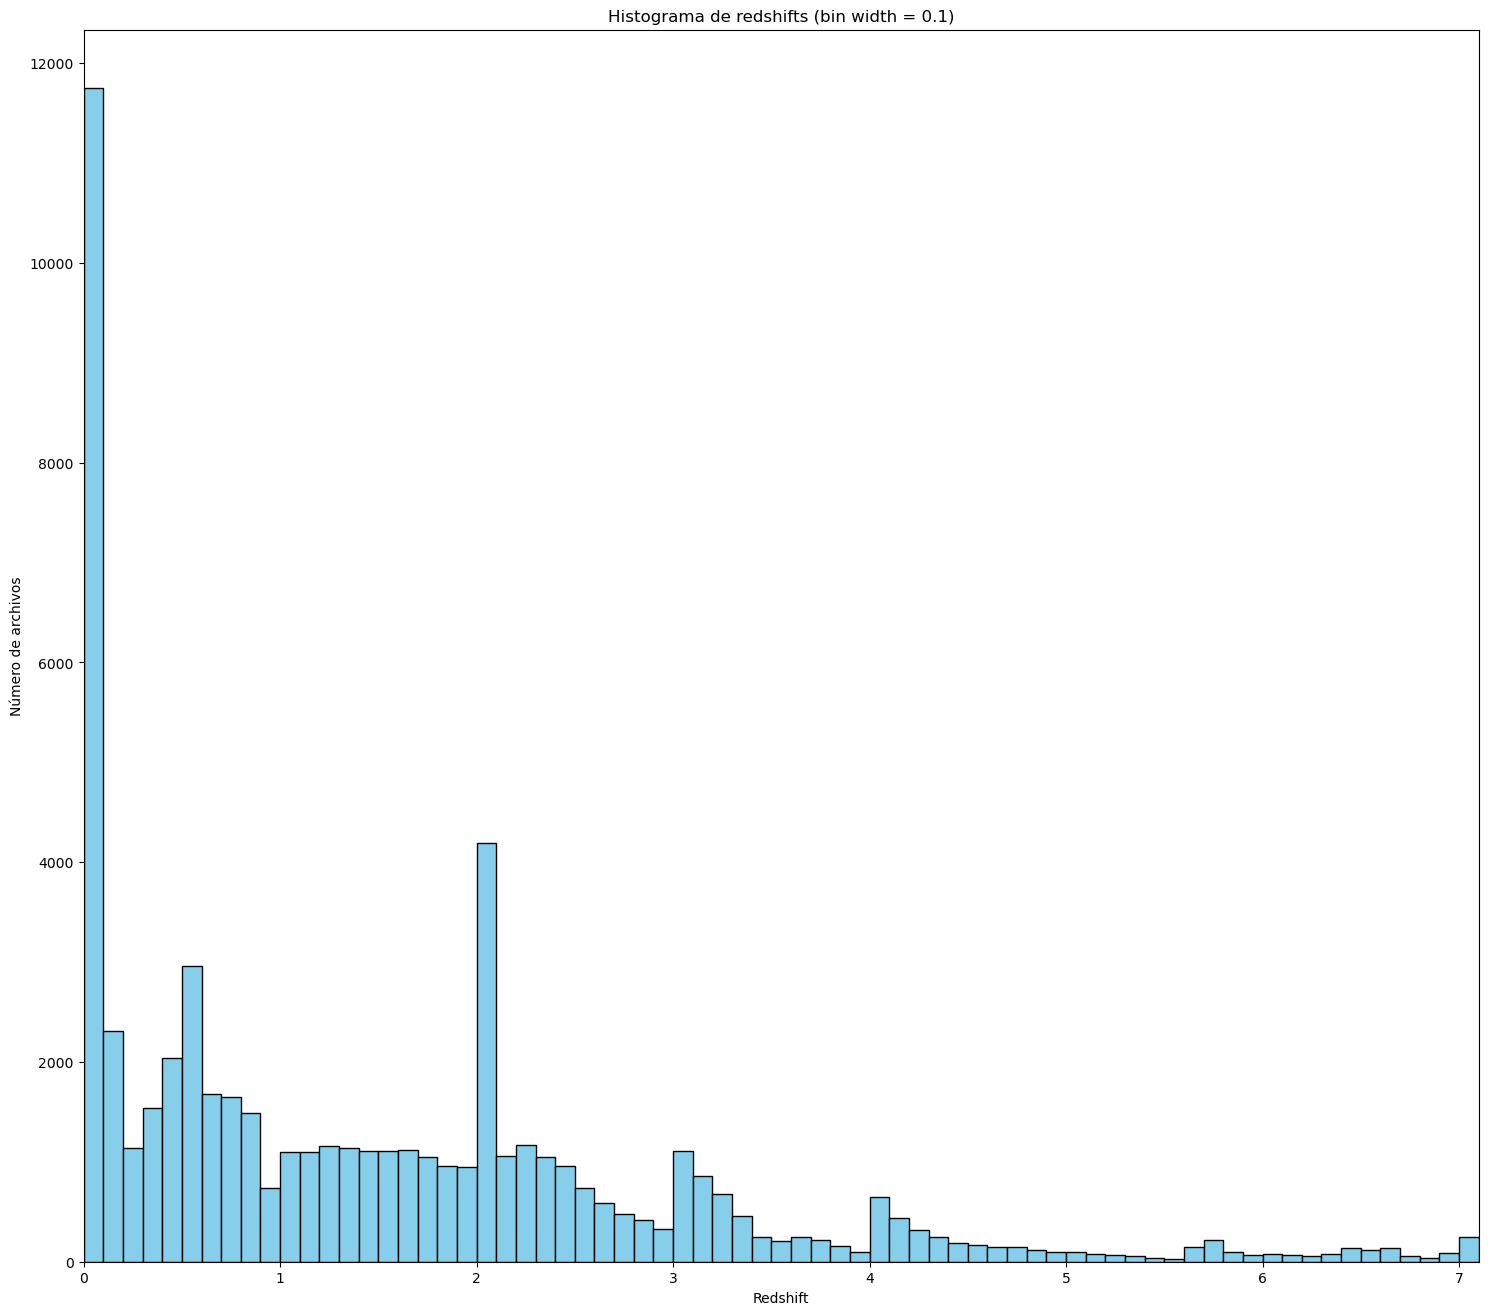

In [1]:
import os
import numpy as np
import pickle
from astropy.io import fits

# Directorio de destino (donde se encuentran los archivos ya copiados)
dst_folder = "spectrums training 100k"

# Lista para almacenar los valores de redshift
redshift_values = []

# Recorrer todos los archivos .fits en la carpeta
for filename in os.listdir(dst_folder):
    if filename.lower().endswith('.fits'):
        file_path = os.path.join(dst_folder, filename)
        try:
            with fits.open(file_path) as hdul:
                # Extraer redshift (se asume que está en la extensión 2, campo "Z")
                redshift = hdul[2].data["Z"][0]
                redshift_values.append(redshift)
        except Exception as e:
            print(f"Error procesando {filename}: {e}")

# Convertir la lista a un arreglo de numpy
redshift_array = np.array(redshift_values)

# Guardar el array de redshifts en un archivo pickle
with open("extra/redshift_array.pkl", "wb") as f:
    pickle.dump(redshift_array, f)

print(f"Guardado redshift_array con {redshift_array.size} elementos en 'redshift_array.pkl'.")

# Opcional: mostrar el histograma original
import matplotlib.pyplot as plt
bins = np.arange(0, redshift_array.max() + 0.1, 0.1)
plt.figure(figsize=(18,16))
plt.hist(redshift_array, bins=bins, color='skyblue', edgecolor='black')
plt.xlabel("Redshift")
plt.ylabel("Número de archivos")
plt.title("Histograma de redshifts (bin width = 0.1)")
plt.xlim(0, 7.1)
plt.show()

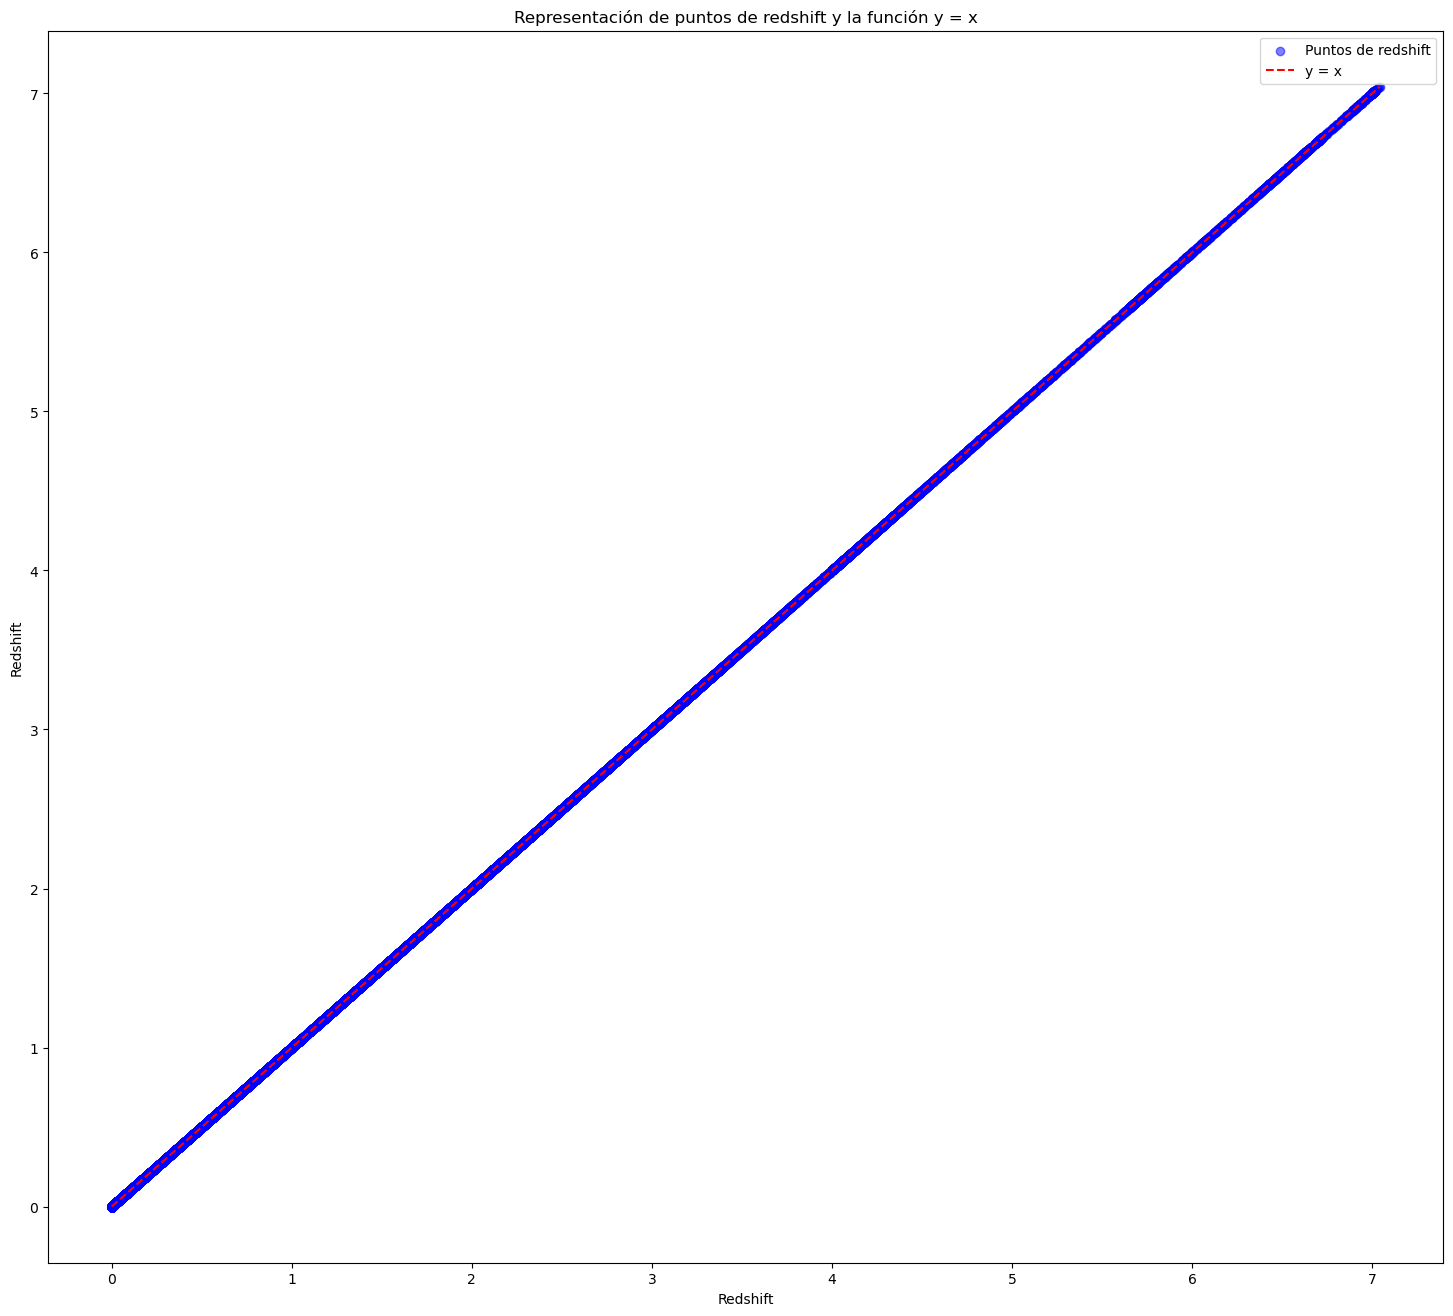

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

# Directorio que contiene los archivos FITS
dst_folder = "spectrums training 100k"

plt.figure(figsize=(18,16))
# Dibujar todos los puntos: cada punto se dibuja en (redshift, redshift)
plt.scatter(redshift_array, redshift_array, color='blue', alpha=0.5, label='Puntos de redshift')

# Dibujar la función y = x
x_vals = np.linspace(0, redshift_array.max(), 100)
plt.plot(x_vals, x_vals, color='red', linestyle='--', label='y = x')

plt.xlabel("Redshift")
plt.ylabel("Redshift")
plt.title("Representación de puntos de redshift y la función y = x")
plt.legend()
plt.show()

Total de redshifts actualizados: 63013
Guardado el array actualizado en 'redshift_array.pkl'.


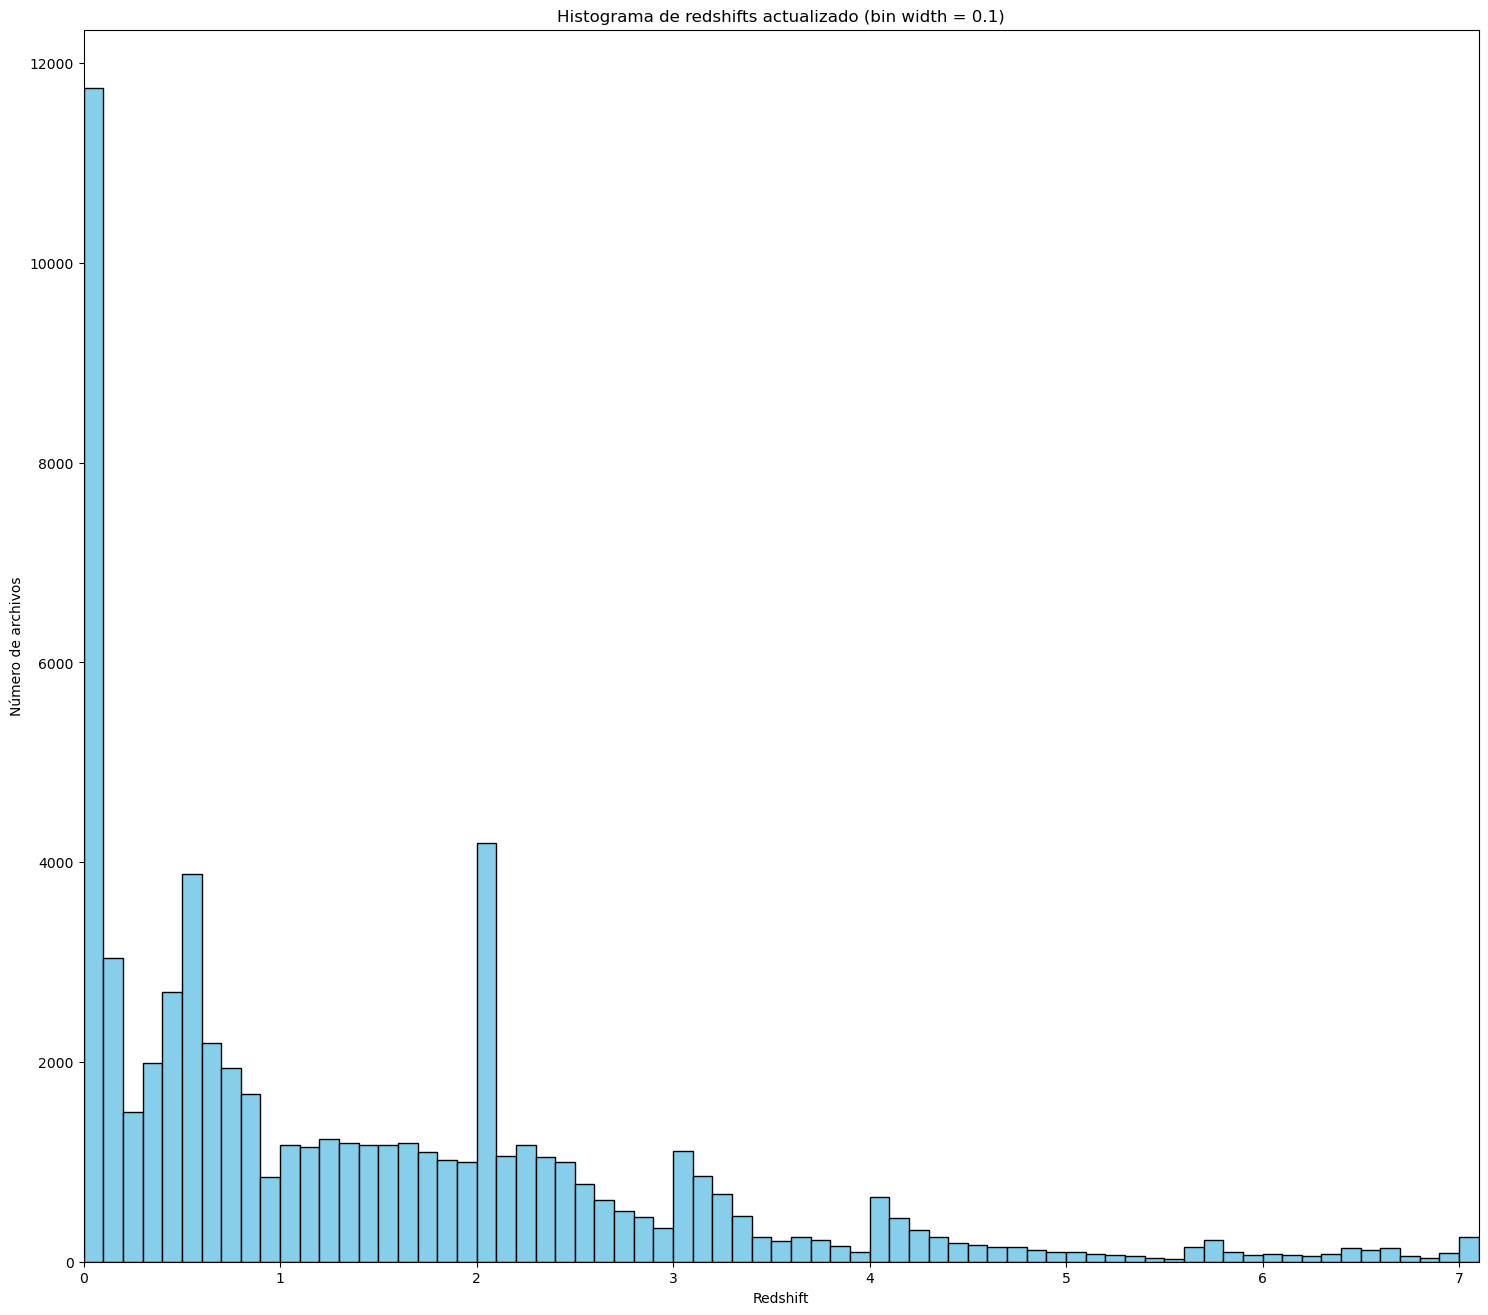

In [3]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt

# Cargar el array original de redshifts desde el pickle
with open("extra/redshift_array.pkl", "rb") as f:
    redshift_array = pickle.load(f)

with open("extra/new_redshifts.pkl", "rb") as f:
    new_redshifts = pickle.load(f)

if isinstance(new_redshifts, dict):
    new_redshifts = np.array(list(new_redshifts.values()))

redshift_array_updated = np.concatenate((redshift_array, new_redshifts))

print(f"Total de redshifts actualizados: {redshift_array_updated.size}")

# Guardar el array actualizado (opcional)
with open("extra/redshift_array.pkl", "wb") as f:
    pickle.dump(redshift_array_updated, f)
print("Guardado el array actualizado en 'redshift_array.pkl'.")

# Definir los bins con intervalos de 0.1 y dibujar el histograma actualizado
bins = np.arange(0, redshift_array_updated.max() + 0.1, 0.1)
plt.figure(figsize=(18,16))
plt.hist(redshift_array_updated, bins=bins, color='skyblue', edgecolor='black')
plt.xlabel("Redshift")
plt.ylabel("Número de archivos")
plt.title("Histograma de redshifts actualizado (bin width = 0.1)")
plt.xlim(0, 7.1)
plt.show()

# Guardar el array de redshifts en un archivo pickle
with open("extra/redshift_array.pkl", "wb") as f:
    pickle.dump(redshift_array_updated, f)

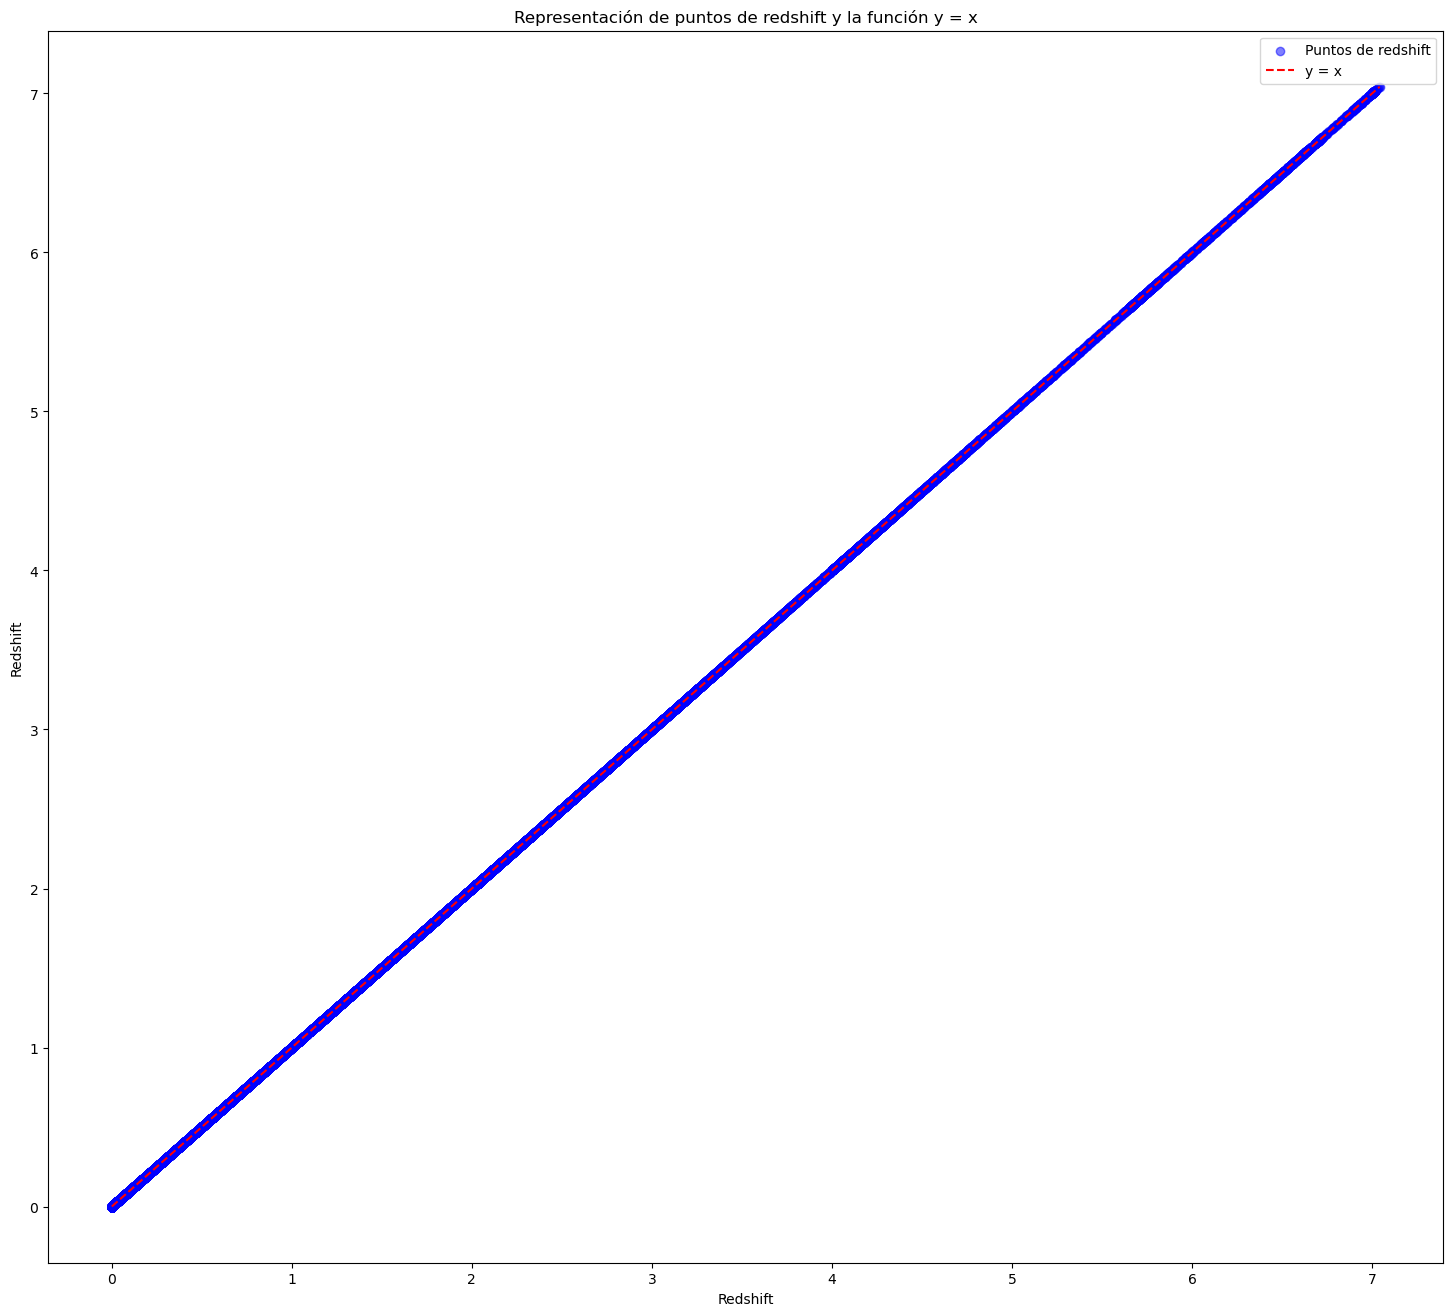

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

# Directorio que contiene los archivos FITS
dst_folder = "spectrums training 100k"

plt.figure(figsize=(18,16))
# Dibujar todos los puntos: cada punto se dibuja en (redshift, redshift)
plt.scatter(redshift_array_updated, redshift_array_updated, color='blue', alpha=0.5, label='Puntos de redshift')

# Dibujar la función y = x
x_vals = np.linspace(0, redshift_array_updated.max(), 100)
plt.plot(x_vals, x_vals, color='red', linestyle='--', label='y = x')

plt.xlabel("Redshift")
plt.ylabel("Redshift")
plt.title("Representación de puntos de redshift y la función y = x")
plt.legend()
plt.show()